# Notebook 8: Final Analysis

This notebook reruns the already-established
computations from Notebooks 4 through 7 in one place, produces the project's final figures
and tables, and states conclusions and limitations directly against what the data showed 
not against what might have been hoped for going in.

Recap of the pipeline this recomputes: on-target knockdown (Notebook 4), the
magnitude/heterogeneity decomposition (Notebook 5), the baseline-state regression (Notebook
6), and the held-out Ridge prediction (Notebook 7). `62(mod)_pBA581` is used as the control
throughout, on the same evidence basis established earlier, well supported, never a
primary-source-confirmed fact.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option("display.max_columns", None)

In [2]:
data_path = "F:/scRNA/adamson_pilot_with_response.h5ad"
adata = sc.read_h5ad(data_path)

control_label = "62(mod)_pBA581"
is_control = (adata.obs["perturbation"] == control_label).values

hvg_mask = adata.var["highly_variable"]
X_hvg = adata[:, hvg_mask].X
X_hvg = np.asarray(X_hvg.todense()) if sp.issparse(X_hvg) else np.asarray(X_hvg)
control_centroid = X_hvg[is_control].mean(axis=0)

In [3]:
target_labels = [c for c in adata.obs["perturbation"].cat.categories if c != control_label]
target_genes = {label: label.split("_")[0] for label in target_labels}

X_all = adata.X.tocsc()
on_target_ratio = {}
for label, gene in target_genes.items():
    if gene not in adata.var_names:
        continue
    gene_col = adata.var_names.get_loc(gene)
    gene_expr = np.asarray(X_all[:, gene_col].todense()).flatten()
    mask_target = (adata.obs["perturbation"] == label).values
    on_target_ratio[label] = gene_expr[mask_target].mean() / gene_expr[is_control].mean()

In [4]:
categories = adata.obs["perturbation"].cat.categories

rows = []
for cat in categories:
    mask = (adata.obs["perturbation"] == cat).values
    group_X = X_hvg[mask]
    group_centroid = group_X.mean(axis=0)
    magnitude = np.linalg.norm(group_centroid - control_centroid)
    heterogeneity = np.sqrt(np.mean(np.sum((group_X - group_centroid) ** 2, axis=1)))
    rows.append({
        "perturbation": cat,
        "n_cells": mask.sum(),
        "on_target_knockdown_ratio": on_target_ratio.get(cat, np.nan),
        "magnitude": magnitude,
        "heterogeneity": heterogeneity,
    })

final_summary = pd.DataFrame(rows).set_index("perturbation")
control_heterogeneity = final_summary.loc[control_label, "heterogeneity"]
final_summary["heterogeneity_ratio_to_control"] = final_summary["heterogeneity"] / control_heterogeneity
final_summary.sort_values("magnitude", ascending=False)

,n_cells,on_target_knockdown_ratio,magnitude,heterogeneity,heterogeneity_ratio_to_control
perturbation,,,,,
SPI1_pDS255,696,0.058946,0.906861,6.401363,1.055777
BHLHE40_pDS258,553,0.185157,0.700858,6.078880,1.002590
SNAI1_pDS266,562,0.000000,0.509289,6.193193,1.021443
DDIT3_pDS263,477,0.183456,0.378645,5.949718,0.981287
ZNF326_pDS262,557,0.181191,0.373506,5.857707,0.966112
EP300_pDS268,632,0.643878,0.342509,5.920628,0.976489
CREB1_pDS269,506,0.310267,0.331550,5.997235,0.989124
62(mod)_pBA581,1769,NaN,0.000000,6.063178,1.000000


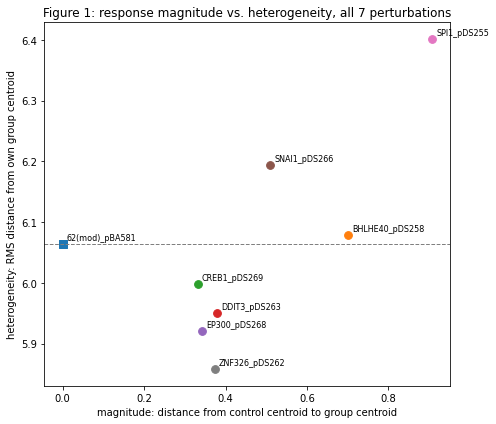

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
for cat in categories:
    row = final_summary.loc[cat]
    marker = "s" if cat == control_label else "o"
    ax.scatter(row["magnitude"], row["heterogeneity"], s=60, marker=marker)
    ax.annotate(str(cat), (row["magnitude"], row["heterogeneity"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(control_heterogeneity, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("magnitude: distance from control centroid to group centroid")
ax.set_ylabel("heterogeneity: RMS distance from own group centroid")
ax.set_title("Figure 1: response magnitude vs. heterogeneity, all 7 perturbations")
plt.tight_layout()
plt.savefig("F:/scRNA/figure1_magnitude_vs_heterogeneity.png", dpi=150)
plt.show()

Baseline-state prediction of response heterogeneity, evaluated on held-out cells:

In [7]:
n_pcs = 10
pca = PCA(n_components=n_pcs, random_state=0)
pcs = pca.fit_transform(X_hvg - X_hvg.mean(axis=0))

deviation = np.zeros(adata.n_obs)
for cat in categories:
    mask = (adata.obs["perturbation"] == cat).values
    centroid = X_hvg[mask].mean(axis=0)
    deviation[mask] = np.linalg.norm(X_hvg[mask] - centroid, axis=1)

feature_table = pd.concat([
    adata.obs[["ncounts", "ngenes", "percent_ribo"]].reset_index(drop=True),
    pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(n_pcs)]),
], axis=1)
target = deviation

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    feature_table.values, target, test_size=0.2, random_state=0,
    stratify=adata.obs["perturbation"].values,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)
test_pred = model.predict(X_test_scaled)

test_r2 = r2_score(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
naive_r2 = r2_score(y_test, np.full_like(y_test, y_train.mean()))

print("held-out test R^2 (technical + baseline PCA features):", test_r2)
print("held-out test RMSE:", test_rmse)
print("naive baseline test R^2:", naive_r2)

held-out test R^2 (technical + baseline PCA features): 0.7910686750037967
held-out test RMSE: 0.5340902584052251
naive baseline test R^2: -0.00024206031913087678


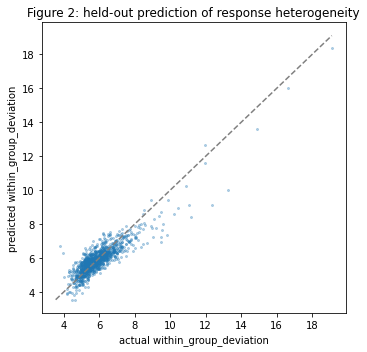

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, test_pred, s=4, alpha=0.3)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlabel("actual within_group_deviation")
ax.set_ylabel("predicted within_group_deviation")
ax.set_title("Figure 2: held-out prediction of response heterogeneity")
plt.tight_layout()
plt.savefig("F:/scRNA/figure2_prediction.png", dpi=150)
plt.show()

In [12]:
final_summary.to_csv("F:/scRNA/final_summary_table.csv")
print("saved to F:/scRNA/final_summary_table.csv")

saved to F:/scRNA/final_summary_table.csv
